In [ ]:
import pandas as pd
import numpy as np
import random
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, mean_squared_error, root_mean_squared_error, confusion_matrix
from scipy.stats import pearsonr
from scipy.spatial.distance import pdist, squareform
!pip install tensorflow-gpu
!pip install tensorflow
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from google.colab import drive
drive.mount('/content/drive')

  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.
Mounted at /content/drive


In [ ]:
# df_org = pd.read_csv('forestfires.csv')
# df = df_org.copy()
# month_map = {'jan': 1, 'feb': 2, 'mar': 3, 'apr': 4, 'may': 5, 'jun': 6,
#              'jul': 7, 'aug': 8, 'sep': 9, 'oct': 10, 'nov': 11, 'dec': 12}
# weeks_map = {'sun': 0, 'mon': 1, 'tue': 2, 'wed': 3, 'thu': 4, 'fri': 5, 'sat': 6}

# df['month_num'] = df['month'].map(month_map)
# df['week_num'] = df['day'].map(weeks_map)


# length = len(df)
# df['index'] = df.index
# # df['label'] = 1  # 1 means normal, 0 mean outlier
# columns_to_remove = {'month', 'day', 'index','label'}

In [ ]:
class DataPreprocessor:
    def __init__(self, df, sel_feature=None, sigma=0.2, OP=1, categorical_maps=None, label_col=None):

        self.df = df.copy()
        self.df_org = df.copy()
        self.sel_feature = sel_feature
        self.sigma = sigma
        self.OUTLIER_PERCENTAGE = OP
        self.length = len(self.df)
        self.COUNT_OUTLIER = int(self.OUTLIER_PERCENTAGE / 100 * self.length)
        self.random_indices = np.random.choice(self.df.index, self.COUNT_OUTLIER, replace=False)
        self.features = []
        self.categorical_maps = categorical_maps or {}
        self.label_col = label_col


    def prepare_data(self):
        self.df = self.df_org.copy()

        # Handle categorical columns
        for col, mapping in self.categorical_maps.items():
            self.df[f'{col}_num'] = self.df[col].map(mapping)
            self.df = self.df.drop(col, errors='ignore',axis=1)
        # Initialize labels if not present
        if self.label_col not in self.df.columns:
            self.df['label'] = 1  # 1 means normal, 0 means outlier

        if self.sel_feature:
            self.df[self.sel_feature] = self.df[self.sel_feature].astype(float)

            # Injecting noise only if feature is specified
            for index in self.random_indices:
                df_1 = self.df.iloc[index].copy()
                temp = df_1[self.sel_feature]
                sigma_T = self.sigma * temp
                noise_T = random.gauss(0, sigma_T)
                temp += noise_T
                df_1[self.sel_feature] = temp
                df_1['label'] = 0
                self.df.loc[index] = df_1

        # features to use (exclude non-feature columns)
        non_feature_cols = {'label'}
        if self.label_col:
            non_feature_cols.add(self.label_col)
        self.features = [col for col in self.df.columns if col not in non_feature_cols]

        self.df = self.df.sample(frac=1).reset_index(drop=True)

        X = self.df[self.features]
        y = self.df['label']
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)

        X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.20, random_state=369, shuffle=False)
        return X_scaled, X_train, X_test, y_train, y_test, self.features
        # return train_test_split(X_scaled, y, test_size=0.20, random_state=369, shuffle=False)


class EnhancedDataPreprocessor(DataPreprocessor):
    @staticmethod
    def get_dataset_config(dataset_name, df=None):
        """Returns only the config for the requested dataset"""
        configs = {
            'forestfires': {
                'categorical_maps': {
                    'month': {'jan':1, 'feb':2, 'mar':3, 'apr':4, 'may':5, 'jun':6,
                              'jul':7, 'aug':8, 'sep':9, 'oct':10, 'nov':11, 'dec':12},
                    'day': {'sun':0, 'mon':1, 'tue':2, 'wed':3, 'thu':4, 'fri':5, 'sat':6}
                },
                'label_col': None
            },
            'pems': {
                'categorical_maps': {},
                'label_col': None
            }
        }

        # Special handling for UNSW as it needs the DataFrame
        if dataset_name == 'unsw' and df is not None:
            configs['unsw'] = {
                'categorical_maps': {
                    'proto': {proto:i for i, proto in enumerate(df['proto'].unique())},
                    'service': {service:i for i, service in enumerate(df['service'].unique())},
                    'attack_cat': {cat:i for i, cat in enumerate(df['attack_cat'].unique())}
                },
                'label_col': 'label'
            }
            return configs.get(dataset_name, {})

        return configs.get(dataset_name, {})

    def __init__(self, df, dataset_name, sel_feature=None, sigma=0.2, OP=1):
        config = self.get_dataset_config(dataset_name, df)
        super().__init__(
            df=df,
            sel_feature=sel_feature,
            sigma=sigma,
            OP=OP,
            categorical_maps=config.get('categorical_maps', None),
            label_col=config.get('label_col', None)
        )

In [ ]:
class ModelTrainer:
    def __init__(self):
        self.models = {}
        self.ae_threshold = None

    def train_rf(self, X_train, y_train, feature_index, feature_name):
        # X_train_feature = X_train[:, feature_index].reshape(-1, 1)
        rf = RandomForestClassifier(n_estimators=10, random_state=42)
        rf.fit(X_train, y_train)
        self.models[f"rf_{feature_name}"] = rf

    def train_knn(self, X_train, y_train, feature_index, feature_name):
        # X_train_feature = X_train[:, feature_index].reshape(-1, 1)
        knn = KNeighborsClassifier(n_neighbors=5)
        knn.fit(X_train, y_train)
        self.models[f"knn_{feature_name}"] = knn

    def train_autoencoder(self, X_train, X_test, data_o, feature_index, feature_name):
        model = AutoEncoder(output_units=X_train.shape[1])

        model.compile(optimizer='adam', loss='msle', metrics=['mse'])
        early_stop = EarlyStopping(monitor='val_loss', patience=5, mode='min')

        # X_train_feature = X_train[:, feature_index].reshape(-1, 1)  # Shape (batch_size, 1)
        # X_test_feature = X_test[:, feature_index].reshape(-1, 1)

        # history = model.fit(X_train, X_train, epochs=100, batch_size=128, validation_split=0.1, verbose=0, callbacks=[early_stop])
        history = model.fit(X_train, X_train, epochs=100, batch_size=128, validation_split=0.1, verbose=0, callbacks=[early_stop])

        reconstructions = model.predict(X_train)
        reconstruction_errors = tf.keras.losses.msle(reconstructions, X_train)
        self.ae_threshold = np.percentile(reconstruction_errors, 100 - data_o.OUTLIER_PERCENTAGE)

        model.threshold = self.ae_threshold
        self.models[f"ae_{feature_name}"] = model



class AutoEncoder(Model):
    def __init__(self, output_units, neck=8):
        super().__init__()
        self.threshold = None
        self.encoder = tf.keras.Sequential([
            Dense(64, activation='relu'),
            Dropout(0.1),
            Dense(32, activation='relu'),
            Dropout(0.1),
            Dense(16, activation='relu'),
            Dropout(0.1),
            Dense(neck, activation='relu')
        ])
        self.decoder = tf.keras.Sequential([
            Dense(16, activation='relu'),
            Dropout(0.1),
            Dense(32, activation='relu'),
            Dropout(0.1),
            Dense(64, activation='relu'),
            Dropout(0.1),
            Dense(output_units, activation='sigmoid')
        ])

    def predict_label(self, inputs):
        encoded = self.encoder(inputs)
        raw = self.decoder(encoded)
        test_errors = tf.keras.losses.msle(raw, inputs)
        ae_preds = (pd.Series(test_errors) > self.threshold).map(lambda x: 0.0 if x else 1.0).astype('float32')
        return ae_preds

    def call(self, inputs):
        encoded = self.encoder(inputs)
        return self.decoder(encoded)

In [ ]:
class Evaluator:
    @staticmethod
    def evaluate(models, X_test, feature_index, y_test):
        print("Evaluation Metrics:")
        # comp_indices = {}
        results = {}

        for name, model in models.items():
            # X_test_feature = X_test[:, feature_index].reshape(-1, 1)
            if name.startswith("ae"):
                preds = model.predict_label(X_test)
            else:
              preds = model.predict(X_test)
        #     comp_indices[name] = [i for i, j in enumerate(preds) if j == 0]
        #     print(f"{name} Accuracy: {accuracy_score(y_test, preds):.4f}")
        #     print(f"{name} F1 Score: {f1_score(y_test, preds):.4f}")
        #     print(f"{name} Precision: {precision_score(y_test, preds):.4f}")
        #     print(f"{name} Recall: {recall_score(y_test, preds):.4f}")
        #     print("__" * 50)
        # return comp_indices
              results[name] = {
                'accuracy': accuracy_score(y_test, preds),
                'f1': f1_score(y_test, preds),
                'precision': precision_score(y_test, preds),
                'recall': recall_score(y_test, preds)
              }
        return results

In [ ]:
tf.random.set_seed(36)
class FIDRecovery:
    def __init__(self):
        self.device = self._detect_hardware()
        self.strategy = self._initialize_strategy()  # Add this method
        self.small_dataset_threshold = 5000
        # Pre-compile TF functions to avoid retracing
        self.compute_fid_tf = tf.function(self.compute_fid,
                # input_signature=[ tf.TensorSpec(shape=[None], dtype=tf.float32),  # org_tensor
                # tf.TensorSpec(shape=[None], dtype=tf.int32)     # comp_indices
             reduce_retracing=True )

    def _initialize_strategy(self):
        if self.device == 'tpu':
            resolver = tf.distribute.cluster_resolver.TPUClusterResolver()
            tf.config.experimental_connect_to_cluster(resolver)
            tf.tpu.experimental.initialize_tpu_system(resolver)
            return tf.distribute.TPUStrategy(resolver)
        elif self.device == 'gpu':
            return tf.distribute.MirroredStrategy()
        else:
            return tf.distribute.get_strategy()  # Adjust based on your needs

    def _detect_hardware(self):
        """Detect available hardware and set appropriate strategies"""
        try:
            if tf.config.list_physical_devices('TPU'):
                # resolver = tf.distribute.cluster_resolver.TPUClusterResolver()
                # tf.config.experimental_connect_to_cluster(resolver)
                # tf.tpu.experimental.initialize_tpu_system(resolver)
                return 'tpu'
            elif tf.config.list_physical_devices('GPU'):
                return 'gpu'
        except:
            pass
        return 'cpu'

    def _should_use_gpu(self, data_size):
        """Heuristic to determine if GPU should be used"""
        if self.device == 'cpu':
            return False
        return data_size > self.small_dataset_threshold

    def calculate_correlation_weights(self, X, target_feature_index, method='pearson'):
        """Automatically selects optimal implementation"""
        if not self._should_use_gpu(X.shape[0]):
            # redictiing to CPU fallback for small datasets
            df_local = pd.DataFrame(X)
            correlation_series = df_local.corr(method=method)[target_feature_index]
            feature_weights = correlation_series.abs().values
            feature_weights[target_feature_index] = 1.0
            return feature_weights / feature_weights.sum()

        # redirect to GPU implementation for pearson
        if method == 'pearson':
            return self._gpu_pearson_correlation(X, target_feature_index)
        else:
            # fallback to CPU for other methods
            return self._cpu_correlation(X, target_feature_index, method)

    def _gpu_pearson_correlation(self, X, target_feature_index):
        """GPU-optimized Pearson correlation"""
        X_tensor = tf.convert_to_tensor(X, dtype=tf.float32)
        target = X_tensor[:, target_feature_index]

        # Center the data
        centered = X_tensor - tf.reduce_mean(X_tensor, axis=0)
        target_centered = target - tf.reduce_mean(target)

        # Compute covariance and variances
        cov = tf.reduce_mean(centered * target_centered[:, tf.newaxis], axis=0)
        var_target = tf.reduce_mean(tf.square(target_centered))
        var_features = tf.reduce_mean(tf.square(centered), axis=0)

        # Compute correlations
        corr = cov / tf.sqrt(var_features * var_target)
        corr = tf.where(tf.math.is_finite(corr), corr, tf.zeros_like(corr))

        # Ensure self-correlation is 1.0
        corr = tf.tensor_scatter_nd_update(corr, [[target_feature_index]], [1.0])
        return (corr / tf.reduce_sum(tf.abs(corr))).numpy()

    def _cpu_correlation(self, X, target_feature_index, method):
        """Fallback CPU implementation"""
        if method == 'distance':
            return self.calculate_distance_correlation_weights(X, target_feature_index)
        else:
            df_local = pd.DataFrame(X)
            correlation_series = df_local.corr(method=method)[target_feature_index]
            feature_weights = correlation_series.abs().values
            feature_weights[target_feature_index] = 1.0
            return feature_weights / feature_weights.sum()

    def calculate_distance_correlation_weights(self, X, target_feature_index):
        """Automatically selects CPU/GPU implementation"""
        if not self._should_use_gpu(X.shape[0]):
            # redict to CPU implementation for small datasets
            target_feature = X[:, target_feature_index]
            weights = []
            for i in range(X.shape[1]):
                if i == target_feature_index:
                    weights.append(1.0)
                else:
                    weights.append(self._cpu_distance_correlation(X[:, i], target_feature))
            weights = np.array(weights)
            return weights / np.sum(weights)
        else:
            # redirecting to GPU implementation
            return self._gpu_distance_correlation_weights(X, target_feature_index)

    def _cpu_distance_correlation(self, x, y):
        """Original CPU implementation"""
        def _dcov(x, y):
            a = squareform(pdist(x[:, None], 'euclidean'))
            b = squareform(pdist(y[:, None], 'euclidean'))
            A = a - a.mean(axis=0)[None, :] - a.mean(axis=1)[:, None] + a.mean()
            B = b - b.mean(axis=0)[None, :] - b.mean(axis=1)[:, None] + b.mean()
            return np.sqrt((A * B).mean())
        return _dcov(x, y) / np.sqrt(_dcov(x, x) * _dcov(y, y))

    def _gpu_distance_correlation_weights(self, X, target_feature_index):
        """Optimized GPU implementation"""
        with self.strategy.scope():
            X_tensor = tf.convert_to_tensor(X, dtype=tf.float32)
            n_features = X_tensor.shape[1]
            batch_size = 512  # Adjust based on your GPU memory

            # Function to compute distance matrices for a batch
            def compute_dist_mats(batch):
                expanded = tf.expand_dims(batch, 1)
                diff = expanded - tf.transpose(expanded, perm=[1, 0, 2])
                return tf.norm(diff, axis=2)

            # Process in batches
            dist_mats = tf.concat([compute_dist_mats(X_tensor[i:i + batch_size])
                for i in range(0, X_tensor.shape[0], batch_size)], axis=0)

            # Center all distance matrices
            means_i = tf.reduce_mean(dist_mats, axis=1, keepdims=True)
            means_j = tf.reduce_mean(dist_mats, axis=2, keepdims=True)
            grand_mean = tf.reduce_mean(dist_mats)
            centered_mats = dist_mats - means_i - means_j + grand_mean

            # Compute correlations
            target_centered = centered_mats[..., target_feature_index]
            covariances = tf.reduce_mean(centered_mats * target_centered[..., tf.newaxis], axis=[0,1])
            var_target = tf.reduce_mean(tf.square(target_centered))
            variances = tf.reduce_mean(tf.square(centered_mats), axis=[0,1])

            # Handle numerical stability
            denominators = tf.sqrt(var_target * variances)
            weights = tf.where(denominators > 1e-8,
                              covariances / denominators,
                              tf.zeros_like(covariances))

            # Ensure self-correlation is 1.0
            weights = tf.tensor_scatter_nd_update(weights,
                                                [[target_feature_index]],
                                                [1.0])
            return (weights / tf.reduce_sum(weights)).numpy()

    def calculate_shallow_nn_weights(self, X, target_feature_index):
        """Automatically selects CPU/GPU implementation"""
        if not self._should_use_gpu(X.shape[0]):
            target_feature = X[:, target_feature_index]
            other_features = np.delete(X, target_feature_index, axis=1)

            nn = MLPRegressor(hidden_layer_sizes=(10,), max_iter=1000,
                             random_state=42)
            nn.fit(other_features, target_feature)

            weights = np.abs(nn.coefs_[0]).mean(axis=1)
            weights = np.insert(weights, target_feature_index, 1.0)
            return weights / np.sum(weights)
        else:
            # GPU implementation
            return self._gpu_shallow_nn(X, target_feature_index)

    def _gpu_shallow_nn(self, X, target_feature_index):
        """GPU-optimized shallow NN"""
        with self.strategy.scope():
            # Force float32 on TPU because its float64 takes hell lot of time(for using gpu its kinda problematic tho)
            policy = tf.keras.mixed_precision.Policy('mixed_float32' if self.device == 'tpu' else 'mixed_float16')
            tf.keras.mixed_precision.set_global_policy(policy)
            X_tensor = tf.convert_to_tensor(X, dtype=tf.float32)
            target = X_tensor[:, target_feature_index]
            features = tf.concat([X_tensor[:, :target_feature_index],
                            X_tensor[:, target_feature_index+1:]], axis=1)

            model = tf.keras.Sequential([
                tf.keras.layers.Dense(10, activation='relu'),
                tf.keras.layers.Dense(1)])
            model.compile(optimizer=tf.keras.optimizers.Adam(0.001), loss='mse')
            # TPUs require fixed batch sizes
            batch_size = 512 * self.strategy.num_replicas_in_sync
            early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss',patience=5, restore_best_weights=True)
            model.fit(features, target, epochs=100, validation_split=0.3, batch_size=batch_size, verbose=0, callbacks=[early_stop])

            weights = tf.reduce_mean(tf.abs(model.layers[0].weights[0]), axis=1)
            weights = tf.concat([
                weights[:target_feature_index],
                [1.0],
                weights[target_feature_index:]
            ], axis=0)

            return (weights / tf.reduce_sum(weights)).numpy()

    def FID(self, org_data, compromised_indices, X=None, target_feature_index=None, method=None):
        """Main entry point with automatic implementation selection"""
        if not self._should_use_gpu(len(org_data)):
            return self._cpu_FID(org_data, compromised_indices, X, target_feature_index, method)
        else:
            return self._gpu_FID(org_data, compromised_indices, X, target_feature_index, method)

    def _cpu_FID(self, org_data, compromised_indices, X=None, target_feature_index=None, method=None):
        """Original CPU implementation with all methods"""
        if method is None:
            # Base FID
            compromised_indices_set = set(compromised_indices)
            observed_data = [val for ind, val in enumerate(org_data) if ind not in compromised_indices_set]

            mean = np.mean(observed_data)
            a, b = min(observed_data), max(observed_data)
            t = len(compromised_indices)
            l = (b - a) / t
            V = [(a + (s - 1) * l + a + s * l) / 2 for s in range(1, t + 1)]

            R = []
            for v in V:
                contribution_weights = [1 - abs(i - v) / l if abs(i - v) <= l else 0 for i in observed_data]
                sum_weights = sum(contribution_weights)
                if sum_weights == 0:
                    R.append(mean)
                else:
                    weighted_sum = sum(w * val for w, val in zip(contribution_weights, observed_data))
                    R.append(weighted_sum / sum_weights)

            recovered_data = np.copy(org_data)
            for i, idx in enumerate(compromised_indices):
                recovered_data[idx] = R[i]
            return recovered_data
        else:
            if method == 'pearson':
                feature_weights = self.calculate_correlation_weights(X, target_feature_index, 'pearson')
            elif method == 'distance':
                feature_weights = self.calculate_distance_correlation_weights(X, target_feature_index)
            elif method == 'shallow_nn':
                feature_weights = self.calculate_shallow_nn_weights(X, target_feature_index)
            else:
                raise ValueError(f"Unknown method: {method}")

            compromised_indices_set = set(compromised_indices)
            observed_data = [val for ind, val in enumerate(org_data) if ind not in compromised_indices_set]
            observed_X = np.delete(X, compromised_indices, axis=0)

            mean = np.mean(observed_data)
            a, b = min(observed_data), max(observed_data)
            t = len(compromised_indices)
            l = (b - a) / t
            V = [(a + (s - 1) * l + a + s * l) / 2 for s in range(1, t + 1)]

            R = []
            for v in V:
                contribution_weights = [1 - abs(i - v) / l if abs(i - v) <= l else 0 for i in observed_data]
                sum_weights = sum(contribution_weights)
                weighted_observed = 0.0
                for i in range(X.shape[1]):
                    if i != target_feature_index:
                        weighted_observed += feature_weights[i] * np.sum(observed_X[:, i] * contribution_weights)
                if sum_weights == 0:
                    R.append(mean)
                else:
                    R.append(weighted_observed / sum_weights)

            recovered_data = np.copy(org_data)
            for i, idx in enumerate(compromised_indices):
                recovered_data[idx] = R[i]
            return recovered_data

    def _gpu_basic_FID(self, org_data, compromised_indices):
        """Optimized GPU implementation of basic FID"""
        # conversion of inputs to tensors
        org_tensor = tf.convert_to_tensor(org_data, dtype=tf.float32)
        comp_indices = tf.convert_to_tensor(compromised_indices, dtype=tf.int32)

        # @tf.function

        # recovered_tensor = self.compute_fid(org_tensor, comp_indices)
        return self.compute_fid_tf(org_tensor, comp_indices).numpy()

    def compute_fid(self, org_tensor, comp_indices):
              # Creating mask for observed data
              mask = tf.ones_like(org_tensor, dtype=tf.bool)
              mask = tf.tensor_scatter_nd_update(
                  mask,
                  tf.expand_dims(comp_indices, 1),
                  tf.zeros_like(comp_indices, dtype=tf.bool))

              observed_data = tf.boolean_mask(org_tensor, mask)
              a, b = tf.reduce_min(observed_data), tf.reduce_max(observed_data)
              t = tf.size(comp_indices)
              l = (b - a) / tf.cast(t, tf.float32)

              s = tf.range(1, t+1, dtype=tf.float32)
              V = (a + (s-1)*l + a + s*l) / 2

              diff = tf.abs(tf.expand_dims(observed_data, 0) - tf.expand_dims(V, 1))
              weights = tf.where(diff <= l, 1 - diff/l, 0.0)

              sum_weights = tf.reduce_sum(weights, axis=1)
              weighted_sum = tf.reduce_sum(weights * tf.expand_dims(observed_data, 0), axis=1)
              R = tf.where(sum_weights > 0,
                          weighted_sum / sum_weights,
                          tf.reduce_mean(observed_data))

              return tf.tensor_scatter_nd_update(org_tensor,tf.expand_dims(comp_indices, 1),R)

    def _gpu_FID(self, org_data, compromised_indices, X=None, target_feature_index=None, method=None):
        if method is None:
            return self._gpu_basic_FID(org_data, compromised_indices)
        else:
            return self._gpu_correlation_FID(org_data, compromised_indices, X, target_feature_index, method)


    def _gpu_correlation_FID(self, org_data, compromised_indices, X, target_feature_index, method):
        org_tensor = tf.convert_to_tensor(org_data, dtype=tf.float32)
        X_tensor = tf.convert_to_tensor(X, dtype=tf.float32)
        comp_indices = tf.convert_to_tensor(compromised_indices, dtype=tf.int32)

        # 1. Calculate weights (GPU-optimized)
        if method == 'pearson':
            weights = self._gpu_pearson_correlation(X_tensor, target_feature_index)
        elif method == 'distance':
            weights = self._gpu_distance_correlation_weights(X_tensor, target_feature_index)
        elif method == 'shallow_nn':
            weights = self._gpu_shallow_nn(X_tensor, target_feature_index)

        # 2. Filter observed data
        observed_mask = tf.ones_like(org_tensor, dtype=tf.bool)
        observed_mask = tf.tensor_scatter_nd_update(
            observed_mask,
            tf.expand_dims(comp_indices, 1),
            tf.zeros_like(comp_indices, dtype=tf.bool)
        )
        observed_data = tf.boolean_mask(org_tensor, observed_mask)
        observed_X = tf.boolean_mask(X_tensor, observed_mask)

        # 3. Recovery intervals
        a, b = tf.reduce_min(observed_data), tf.reduce_max(observed_data)
        t = tf.size(comp_indices)
        l = (b - a) / tf.cast(t, tf.float32)
        s = tf.range(1, t+1, dtype=tf.float32)
        V = (a + (s-1)*l + a + s*l) / 2

        # 4. CRITICAL FIX: Apply weights like CPU version
        diff = tf.abs(tf.expand_dims(observed_data, 0) - tf.expand_dims(V, 1))  # Shape: [t, n_observed]
        contrib_weights = tf.where(diff <= l, 1 - diff/l, 0.0)  # Shape: [t, n_observed]

        # Vectorized equivalent of your CPU's weighted sum:
        # For each feature i: sum(observed_X[:,i] * contrib_weights[t,:]) * feature_weights[i]
        weighted_contributions = tf.einsum(
            'ji,tj->ti',  # observed_X.T [features x n_observed] @ contrib_weights [t x n_observed]
            observed_X * weights[None, :],  # Applying feature weights
            contrib_weights)

        # Sum across features (excluding target)
        mask = tf.one_hot(target_feature_index, X.shape[1], on_value=0.0, off_value=1.0)
        weighted_observed = tf.reduce_sum(weighted_contributions * mask, axis=1)  # Shape: [t]

        sum_weights = tf.reduce_sum(contrib_weights, axis=1)  # Shape: [t]
        R = tf.where(sum_weights > 0, weighted_observed / sum_weights, tf.reduce_mean(observed_data))


        return tf.tensor_scatter_nd_update(org_tensor,tf.expand_dims(comp_indices, 1),R).numpy()

In [ ]:
# evaluator = Evaluator()
# trainers = {}

# for feature in ['temp', 'RH']:
#   preprocessor = DataPreprocessor(df, feature, sigma=0.6, OP=20)
#   X_scaled, X_train, X_test, y_train, y_test, features = preprocessor.prepare_data()
#   print(f"For feature: {feature}")

#   feature_index = features.index(feature)
#   trainers[f"{feature}"] = ModelTrainer()

#   trainers[feature].train_rf(X_train, y_train, feature_index, feature)
#   trainers[feature].train_knn(X_train, y_train, feature_index, feature)
#   trainers[feature].train_autoencoder(X_train, X_test, preprocessor, feature_index, feature)
#   model_names = [f"rf_{feature}",f"knc_{feature}"]
#   # var_name3 = f"ae_{feature}"

#   #pending  (:p

#   combined_series = pd.concat([y_train, y_test])
#   # compromised_indices = np.where(combined_series == 0)[0]

#   com_indices = evaluator.evaluate(trainers[feature].models, X_test, feature_index, y_test)
#   # RF_compromised_indices = com_indices[f"rf_{feature}"]
#   # KNC_compromised_indices = com_indices[f"knc_{feature}"]
#   ytest_count_outliers = sum(1 for i, j in enumerate(y_test) if j == 0)

#   print(f"Actual  compromised data instances : {ytest_count_outliers}")
#   for key, value in com_indices.items():
#     print(f"For {key}, compromised data instances: {len(value)}")
#   print("\n")
#   # print(f"For  RF, compromised data instances: {len(RF_compromised_indices)}")
#   # print(f"For KNN, compromised data instances: {len(KNC_compromised_indices)}\n")
#   # print(f"For AE, compromised data instances: {len(AE_compromised_indices)}]\n")
#   print("**"*80,"\n\n")


		===  Processing unsw dataset  ===

Analyzing feature: dur
  Sigma: 0.2 | Done
  Sigma: 0.3 | Done
  Sigma: 0.4 | Done
  Sigma: 0.5 | Done
  Outlier %: 5 | Done
  Outlier %: 10 | Done
  Outlier %: 15 | Done
  Outlier %: 20 | Done

Analyzing feature: rate
  Sigma: 0.2 | Done
  Sigma: 0.3 | Done
  Sigma: 0.4 | Done
  Sigma: 0.5 | Done
  Outlier %: 5 | Done
  Outlier %: 10 | Done
  Outlier %: 15 | Done
  Outlier %: 20 | Done


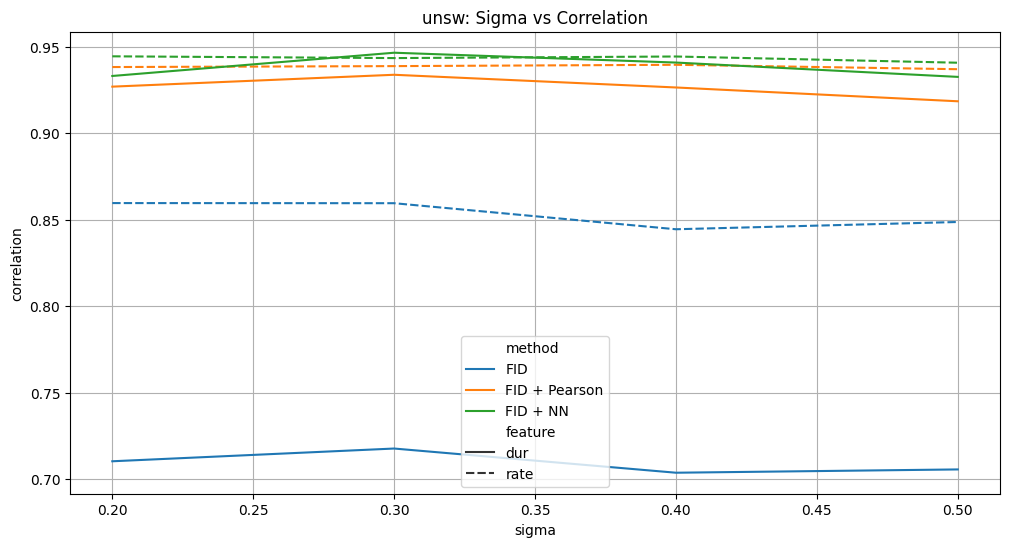

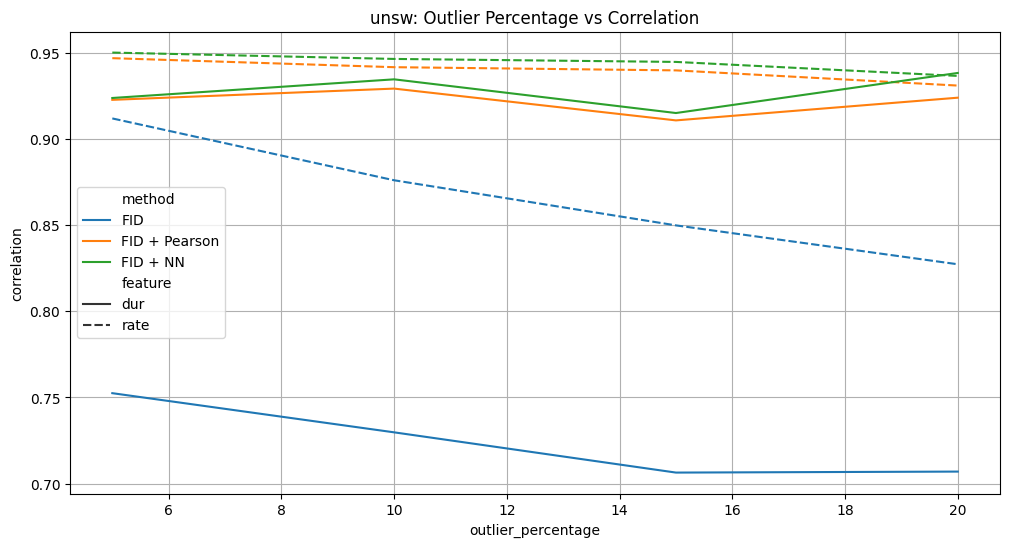

In [ ]:
# code block for collecting results of original vs recovered data correlation for both FID and modified FID.

import seaborn as sns
import matplotlib.pyplot as plt
import gc

def preprocess_pems(df):
    # Ensure datetime index (if not already)
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.iloc[:, 0])  # Assuming first column is datetime
        df = df.iloc[:, 1:]  # Drop the original datetime column if duplicated

    df['minute'] = df.index.minute
    df['hour'] = df.index.hour
    df['day_of_week'] = df.index.dayofweek  # Monday=0, Sunday=6
    df['is_weekend'] = df['day_of_week'] >= 5


    df = df.dropna().reset_index(drop=True)

    return df



def analyze_datasets():

    DATASETS = {
        'forestfires': {
            'file': '/content/drive/My Drive/MTP_DATA/forestfires.csv',
            'features': ['temp', 'RH'],
            'preprocess': lambda df: df  # No special preprocessing
        }
        # ,
        # 'pems': {
        #     'file': '/content/drive/My Drive/MTP_DATA/PEMS-BAY.csv',
        #     'features': ['400001', '400017'],  # Sensor IDs from paper
        #     'preprocess': preprocess_pems,  # Preprocessing function
        #     'no_drop' : ['minute','hour','day_of_week','is_weekend']
        # }
        # ,
        # 'unsw': {
        #     'file': '/content/drive/My Drive/MTP_DATA/UNSW_NB15/UNSW_NB15_test.csv',
        #     'features': ['dur', 'rate'],  # Features from paper
        #     'preprocess': lambda df: df.drop(['state'], axis=1) #lambda df: df.select_dtypes(include=[np.number])  # Numerical only
        # }
    }


    fid = FIDRecovery()


    sigma_values = [0.2, 0.3, 0.4, 0.5]
    outlier_percentages = [5, 10, 15, 20]
    fixed_outlier_percentage = 15
    fixed_sigma = 0.3

    all_results = []

    for dataset_name, config in DATASETS.items():
        print(f"\n\t\t===  Processing {dataset_name} dataset  ===")

        df = pd.read_csv(config['file'])
        # print("Columns in dataset:", df.columns.tolist())
        df = config['preprocess'](df)

        # clearing any existing TensorFlow graphs to prevent memory buildup
        tf.keras.backend.clear_session()
        gc.collect()

        dataset_results = {'sigma': [], 'outlier': []}
        # if dataset_name == 'pems':
        #     df = df[config['no_drop']+config['features']]

        for feature in config['features']:
            print(f"\nAnalyzing feature: {feature}")
            if dataset_name == 'pems':
                features_to_keep = [feature] + config['no_drop']
                df_n = df[features_to_keep]
            else:
                df_n = df

            # Sigma variation analysis
            for sigma in sigma_values:
                print(f"  Sigma: {sigma}", end=" | ")

                # Initialize preprocessor
                try:
                    preprocessor = EnhancedDataPreprocessor(
                        df= df_n, #if dataset_name=='pems' else df,
                        dataset_name=dataset_name,
                        sel_feature=feature,
                        sigma=sigma,
                        OP=fixed_outlier_percentage
                    )
                    # Prepare data with injected outliers
                    X_scaled, X_train, X_test, y_train, y_test, features = preprocessor.prepare_data()
                    feature_index = features.index(feature)
                    compromised_indices = np.where(y_test == 0)[0]
                    original_data = X_scaled[:, feature_index]

                    # Test all recovery methods
                    # methods = {
                    #     'FID': fid.FID(original_data, compromised_indices),
                    #     'FID + Pearson': fid.FID(original_data, compromised_indices,
                    #                            X_scaled, feature_index, method='pearson'),
                    #     # 'FID + Distance': fid.FID(original_data, compromised_indices,
                    #     #                         X_scaled, feature_index, method='distance'),
                    #     # 'FID + Distance': fid.FID_with_distance_correlation(original_data,
                    #     #                                                   compromised_indices,
                    #     #                                                   X_scaled, feature_index),
                    #     'FID + NN': fid.FID(original_data, compromised_indices,
                    #                             X_scaled, feature_index, method='shallow_nn'),
                    # }

                    # with explicit clearing intermediate tensors to tackle memory buildup
                    methods = {}
                    methods['FID'] = fid.FID(original_data, compromised_indices)

                    # Clear intermediate tensors
                    tf.keras.backend.clear_session()

                    methods['FID + Pearson'] = fid.FID(
                        original_data, compromised_indices,
                        X_scaled, feature_index, method='pearson')

                    tf.keras.backend.clear_session()

                    methods['FID + NN'] = fid.FID(
                        original_data, compromised_indices,
                        X_scaled, feature_index, method='shallow_nn')

                    # Store results
                    for method_name, recovered in methods.items():
                        corr, _ = pearsonr(original_data, recovered)
                        dataset_results['sigma'].append({
                            'dataset': dataset_name,
                            'feature': feature,
                            'method': method_name,
                            'sigma': sigma,
                            'correlation': corr
                        })

                    # Explicit cleanup
                    del X_scaled, X_train, X_test, y_train, y_test, original_data
                    tf.keras.backend.clear_session()

                    print("Done")

                except Exception as e:
                    print(f"Error processing sigma {sigma}: {str(e)}")
                    continue

            # Outlier percentage variation analysis
            for OP in outlier_percentages:
                print(f"  Outlier %: {OP}", end=" | ")

                try:
                    preprocessor = EnhancedDataPreprocessor(
                        df=df_n, #if dataset_name=='pems' else df,
                        dataset_name=dataset_name,
                        sel_feature=feature,
                        sigma=fixed_sigma,
                        OP=OP
                    )

                    X_scaled, X_train, X_test, y_train, y_test, features = preprocessor.prepare_data()
                    feature_index = features.index(feature)
                    compromised_indices = np.where(y_test == 0)[0]
                    original_data = X_scaled[:, feature_index]

                    # methods = {
                    #     'FID': fid.FID(original_data, compromised_indices),
                    #     'FID + Pearson': fid.FID(original_data, compromised_indices,
                    #                            X_scaled, feature_index, method='pearson'),
                    #     # 'FID + Distance': fid.FID(original_data, compromised_indices,
                    #     #                         X_scaled, feature_index, method='distance'),
                    #     # 'FID + Distance': fid.FID_with_distance_correlation(original_data,
                    #     #                                                   compromised_indices,
                    #     #                                                   X_scaled, feature_index),
                    #     'FID + NN': fid.FID(original_data, compromised_indices,
                    #                             X_scaled, feature_index, method='shallow_nn'),
                    # }

                    #with explicit clearing intermediate tensors to tackle memory buildup
                    methods = {}
                    methods['FID'] = fid.FID(original_data, compromised_indices)

                    # Clear intermediate tensors
                    tf.keras.backend.clear_session()

                    # Process Pearson version
                    methods['FID + Pearson'] = fid.FID(
                        original_data, compromised_indices,
                        X_scaled, feature_index, method='pearson')

                    tf.keras.backend.clear_session()

                    # Process NN version
                    methods['FID + NN'] = fid.FID(
                        original_data, compromised_indices,
                        X_scaled, feature_index, method='shallow_nn')

                    for method_name, recovered in methods.items():
                        corr, _ = pearsonr(original_data, recovered)
                        dataset_results['outlier'].append({
                            'dataset': dataset_name,
                            'feature': feature,
                            'method': method_name,
                            'outlier_percentage': OP,
                            'correlation': corr
                        })
                    # Explicit cleanup
                    del X_scaled, X_train, X_test, y_train, y_test, original_data
                    tf.keras.backend.clear_session()

                    print("Done")

                except Exception as e:
                    print(f"Error processing sigma {sigma}: {str(e)}")
                    continue

        # Convert to DataFrames
        sigma_df = pd.DataFrame(dataset_results['sigma'])
        outlier_df = pd.DataFrame(dataset_results['outlier'])
        all_results.append((sigma_df, outlier_df))

    return all_results

# Run analysis and visualize results
def visualize_results(all_results):
    for sigma_df, outlier_df in all_results:
        dataset_name = sigma_df['dataset'].iloc[0]

        # Sigma vs Correlation plot
        plt.figure(figsize=(12, 6))
        sns.lineplot(data=sigma_df, x='sigma', y='correlation', hue='method', style='feature')
        plt.title(f'{dataset_name}: Sigma vs Correlation')
        plt.grid(True)
        plt.show()

        # Outlier Percentage vs Correlation plot
        plt.figure(figsize=(12, 6))
        sns.lineplot(data=outlier_df, x='outlier_percentage', y='correlation', hue='method', style='feature')
        plt.title(f'{dataset_name}: Outlier Percentage vs Correlation')
        plt.grid(True)
        plt.show()


results = analyze_datasets()
visualize_results(results)

In [ ]:
import pickle

# Save
# with open('/content/drive/My Drive/MTP_DATA/results_of_unsw1.pkl', 'wb') as f:
#     pickle.dump(results, f)

# Load
# with open('/content/drive/My Drive/MTP_DATA/results_of_unsw.pkl', 'rb') as f:
#     loaded_data = pickle.load(f)
#     print(loaded_data)

[(   dataset feature         method  sigma  correlation
0     unsw     dur            FID    0.2     0.710400
1     unsw     dur  FID + Pearson    0.2     0.926847
2     unsw     dur       FID + NN    0.2     0.933012
3     unsw     dur            FID    0.3     0.717761
4     unsw     dur  FID + Pearson    0.3     0.933710
5     unsw     dur       FID + NN    0.3     0.946448
6     unsw     dur            FID    0.4     0.703786
7     unsw     dur  FID + Pearson    0.4     0.926369
8     unsw     dur       FID + NN    0.4     0.940767
9     unsw     dur            FID    0.5     0.705687
10    unsw     dur  FID + Pearson    0.5     0.918393
11    unsw     dur       FID + NN    0.5     0.932487
12    unsw    rate            FID    0.2     0.859580
13    unsw    rate  FID + Pearson    0.2     0.938173
14    unsw    rate       FID + NN    0.2     0.944368
15    unsw    rate            FID    0.3     0.859504
16    unsw    rate  FID + Pearson    0.3     0.938713
17    unsw    rate       F

In [ ]:
# Print the actual correlation values for comparison
for sigma_df, outlier_df in results:
    print("\nSigma variations:")
    print(sigma_df.groupby(['feature', 'method'])['correlation'].mean())

    print("\nOutlier variations:")
    print(outlier_df.groupby(['feature', 'method'])['correlation'].mean())


Sigma variations:
feature  method       
dur      FID              0.709408
         FID + NN         0.938178
         FID + Pearson    0.926330
rate     FID              0.853046
         FID + NN         0.943165
         FID + Pearson    0.938320
Name: correlation, dtype: float64

Outlier variations:
feature  method       
dur      FID              0.723903
         FID + NN         0.927808
         FID + Pearson    0.921542
rate     FID              0.866184
         FID + NN         0.944329
         FID + Pearson    0.939698
Name: correlation, dtype: float64


In [ ]:
# def visualize_results2(all_results):
#     for sigma_df, outlier_df in all_results:
#         dataset_name = sigma_df['dataset'].iloc[0]

#         # Get unique features and methods
#         features = sigma_df['feature'].unique()
#         methods = sigma_df['method'].unique()

#         # Create a color palette
#         palette = sns.color_palette("husl", len(methods))

#         # Plot for each feature separately
#         for feature in features:
#             # Filter data for current feature
#             feature_sigma_df = sigma_df[sigma_df['feature'] == feature]
#             feature_outlier_df = outlier_df[outlier_df['feature'] == feature]

#             # Create figure with subplots
#             fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
#             fig.suptitle(f'{dataset_name} - Feature: {feature}', fontsize=14)

#             # Add jitter to x-axis values
#             jitter_amount = 0.02  # Adjust as needed

#             # Plot 1: Sigma vs Correlation
#             for i, method in enumerate(methods):
#                 method_df = feature_sigma_df[feature_sigma_df['method'] == method]
#                 # Add small jitter to x values
#                 jittered_sigma = method_df['sigma'] + np.random.uniform(-jitter_amount, jitter_amount, len(method_df))
#                 sns.lineplot(
#                     x=jittered_sigma,
#                     y=method_df['correlation'],
#                     color=palette[i],
#                     label=method,
#                     ax=ax1,
#                     linewidth=2.5,
#                     alpha=0.8
#                 )
#                 # Add scatter points
#                 sns.scatterplot(
#                     x=jittered_sigma,
#                     y=method_df['correlation'],
#                     color=palette[i],
#                     ax=ax1,
#                     s=80,
#                     edgecolor='w'
#                 )

#             ax1.set_title('Sigma vs Correlation')
#             ax1.set_xlabel('Sigma')
#             ax1.set_ylabel('Correlation')
#             ax1.grid(True, alpha=0.3)

#             # Plot 2: Outlier Percentage vs Correlation
#             for i, method in enumerate(methods):
#                 method_df = feature_outlier_df[feature_outlier_df['method'] == method]
#                 # Add small jitter to x values
#                 jittered_op = method_df['outlier_percentage'] + np.random.uniform(-jitter_amount, jitter_amount, len(method_df))
#                 sns.lineplot(
#                     x=jittered_op,
#                     y=method_df['correlation'],
#                     color=palette[i],
#                     label=method,
#                     ax=ax2,
#                     linewidth=2.5,
#                     alpha=0.8
#                 )
#                 # Add scatter points
#                 sns.scatterplot(
#                     x=jittered_op,
#                     y=method_df['correlation'],
#                     color=palette[i],
#                     ax=ax2,
#                     s=80,
#                     edgecolor='w'
#                 )

#             ax2.set_title('Outlier Percentage vs Correlation')
#             ax2.set_xlabel('Outlier Percentage')
#             ax2.set_ylabel('Correlation')
#             ax2.grid(True, alpha=0.3)

#             # Common adjustments
#             for ax in [ax1, ax2]:
#                 ax.legend(title='Method', bbox_to_anchor=(1.05, 1), loc='upper left')
#                 ax.set_ylim(0, 1.1)  # Correlation ranges from 0 to 1

#             plt.tight_layout()
#             plt.show()
# visualize_results2(results)

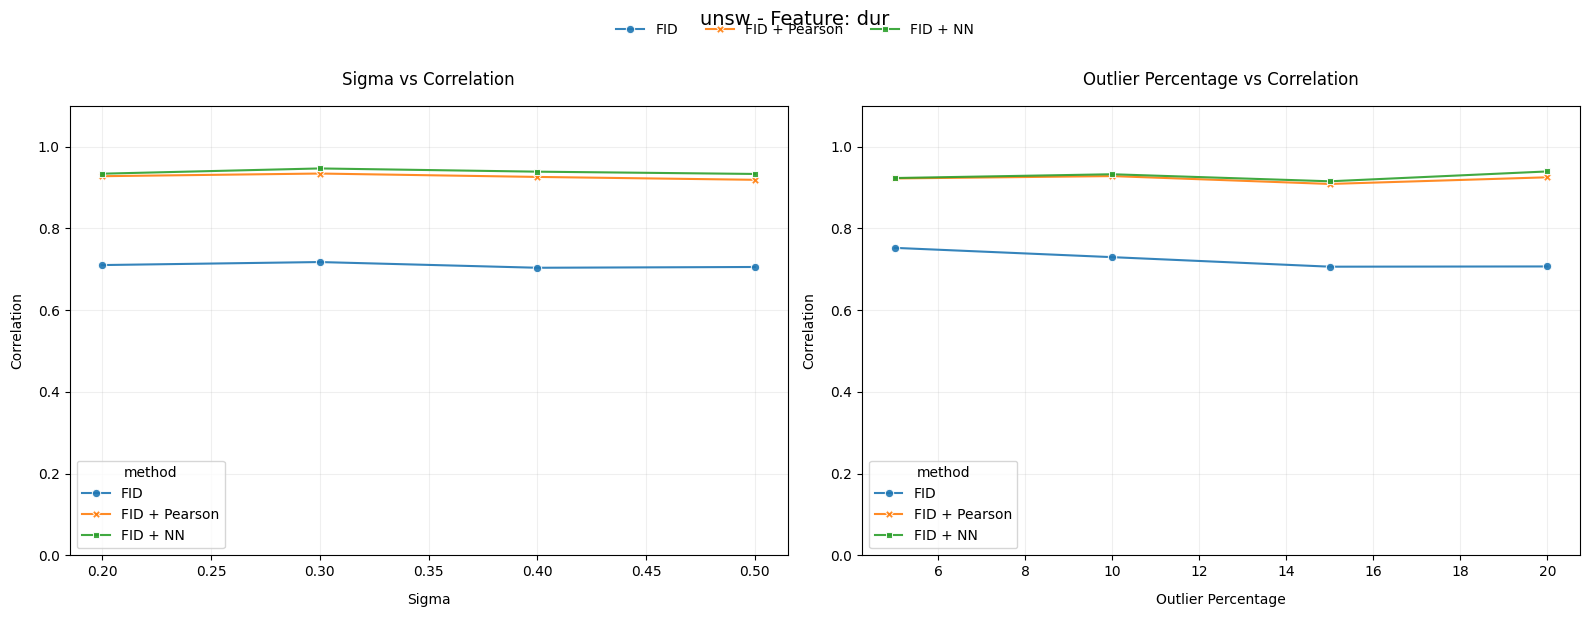

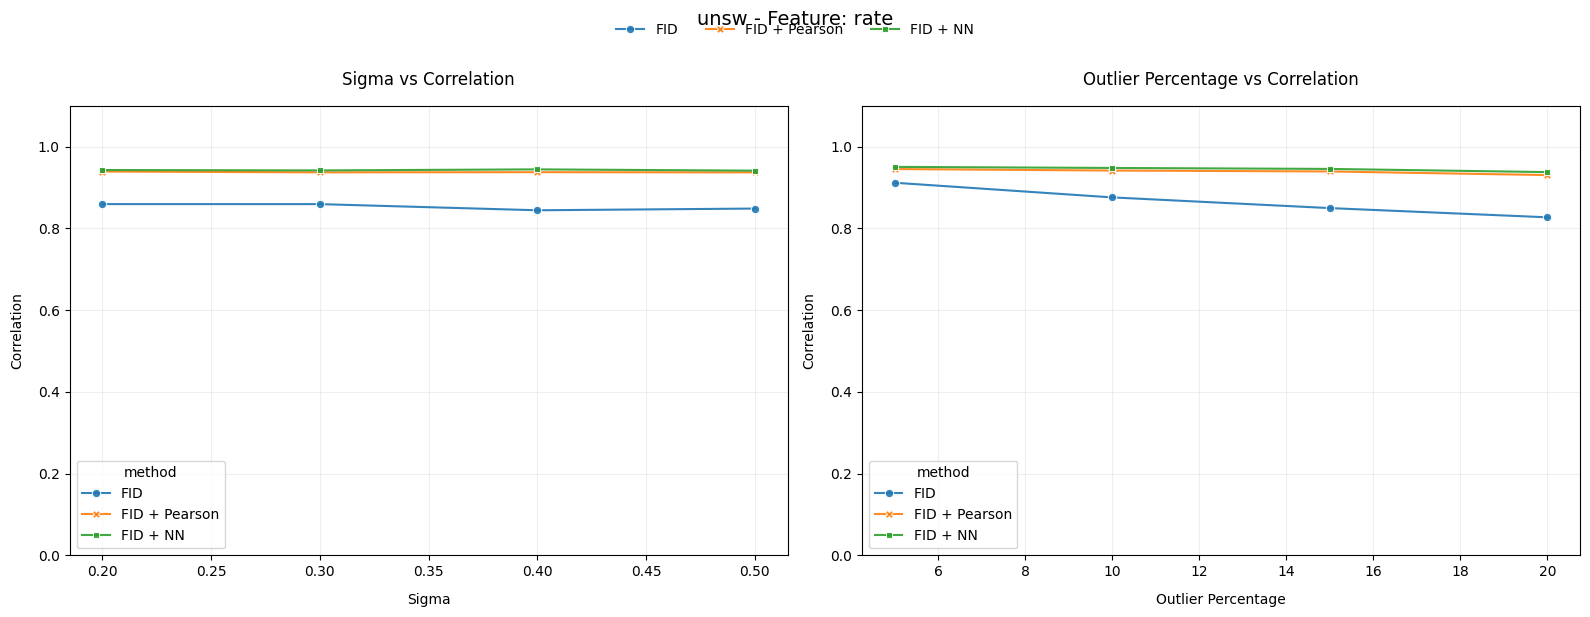

In [ ]:
def visualize_results3(all_results):
    for sigma_df, outlier_df in all_results:
        dataset_name = sigma_df['dataset'].iloc[0]
        features = sigma_df['feature'].unique()

        # Configuration
        jitter_strength = 0.0019
        marker_size = 6
        line_width = 1.5
        alpha = 0.9

        for feature in features:
            # Prepare data for current feature
            feature_sigma_df = sigma_df[sigma_df['feature'] == feature].copy()
            feature_outlier_df = outlier_df[outlier_df['feature'] == feature].copy()

            for df in [feature_sigma_df, feature_outlier_df]:
                df['correlation_jittered'] = df['correlation'] + df['method'].apply(
                    lambda m: np.random.uniform(-jitter_strength, jitter_strength)
                    if 'FID' in m and m != 'FID' else 0
                )

            # Create figure
            plt.figure(figsize=(16, 6))
            plt.suptitle(f'{dataset_name} - Feature: {feature}', y=1.02, fontsize=14)

            # ===== Sigma vs Correlation =====
            plt.subplot(1, 2, 1)
            sns.lineplot(
                data=feature_sigma_df,
                x='sigma',
                y='correlation_jittered',
                hue='method',
                style='method',
                markers=True,
                dashes=False,
                markersize=marker_size,
                linewidth=line_width,
                alpha=alpha,
                markeredgecolor='w'
            )
            plt.title('Sigma vs Correlation', pad=15)
            plt.xlabel('Sigma', labelpad=10)
            plt.ylabel('Correlation', labelpad=10)
            plt.grid(True, alpha=0.2)
            plt.ylim(0, 1.1)

            # ===== Outlier Percentage vs Correlation =====
            plt.subplot(1, 2, 2)
            sns.lineplot(
                data=feature_outlier_df,
                x='outlier_percentage',
                y='correlation_jittered',
                hue='method',
                style='method',
                markers=True,
                dashes=False,
                markersize=marker_size,
                linewidth=line_width,
                alpha=alpha,
                markeredgecolor='w'
            )
            plt.title('Outlier Percentage vs Correlation', pad=15)
            plt.xlabel('Outlier Percentage', labelpad=10)
            plt.ylabel('Correlation', labelpad=10)
            plt.grid(True, alpha=0.2)
            plt.ylim(0, 1.1)

            # Adjust legend
            handles, labels = plt.gca().get_legend_handles_labels()
            plt.figlegend(
                handles, labels,
                loc='upper center',
                ncol=min(4, len(labels)),  # Max 4 columns
                bbox_to_anchor=(0.5, 1.02),
                frameon=False
            )

            plt.tight_layout()
            plt.show()

visualize_results3(results)